In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/kaggle/input/datasets/yasserh/titanic-dataset/Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df = df.drop(['PassengerId','Ticket', 'Name'], axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Cabin     204 non-null    object 
 8   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 62.8+ KB


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Cabin     204 non-null    object 
 8   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 62.8+ KB


In [5]:
df = df.drop('Cabin', axis=1)

In [6]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [8]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    2
dtype: int64

In [9]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [10]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [11]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [12]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


<function matplotlib.pyplot.show(close=None, block=None)>

<Figure size 2000x1000 with 0 Axes>

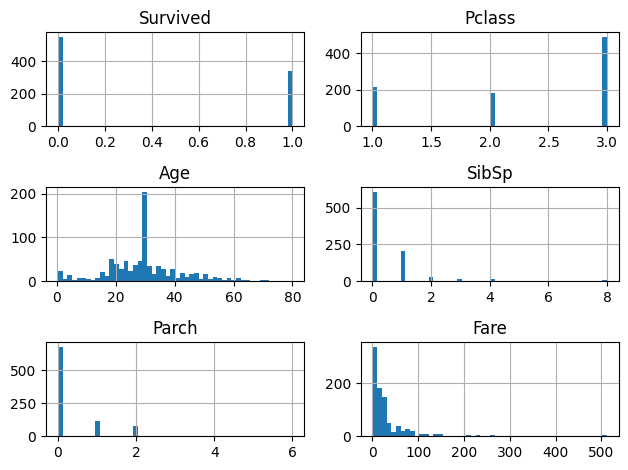

In [13]:
plt.figure(figsize=(20,10))
df.hist(bins=50)
plt.tight_layout()
plt.show

In [14]:
df['Sex'] = df['Sex'].map({"female":0, "male": 1})

In [15]:
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

In [16]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,False,True
1,1,1,0,38.0,1,0,71.2833,False,False
2,1,3,0,26.0,0,0,7.9250,False,True
3,1,1,0,35.0,1,0,53.1000,False,True
4,0,3,1,35.0,0,0,8.0500,False,True


In [17]:
df.groupby('Sex')['Survived'].mean()

Sex
0    0.742038
1    0.188908
Name: Survived, dtype: float64

In [18]:
for col in ['Sex', 'Pclass']:
    print(f"\n{col}:")
    print(df.groupby(col)['Survived'].mean())


Sex:
Sex
0    0.742038
1    0.188908
Name: Survived, dtype: float64

Pclass:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


/tmp/ipykernel_16/1248607631.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


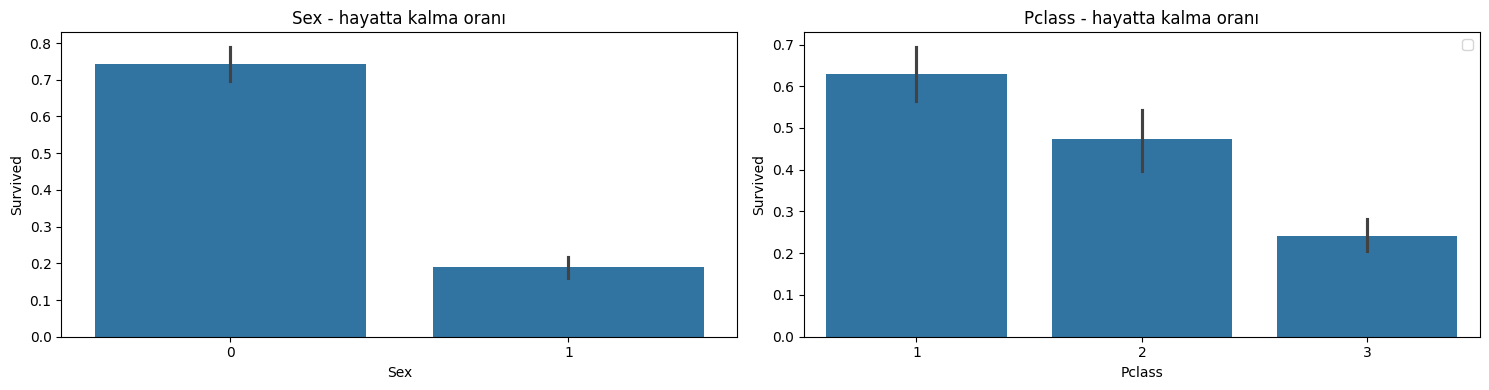

In [19]:
fig, axes = plt.subplots(1,2, figsize=(15,4))

for i, col in enumerate(['Sex', 'Pclass']):
    sns.barplot(data=df, x=col, y='Survived', ax=axes[i])
    axes[i].set_title(f"{col} - hayatta kalma oranı")
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
sayılar = df['Pclass'].value_counts()

<function matplotlib.pyplot.show(close=None, block=None)>

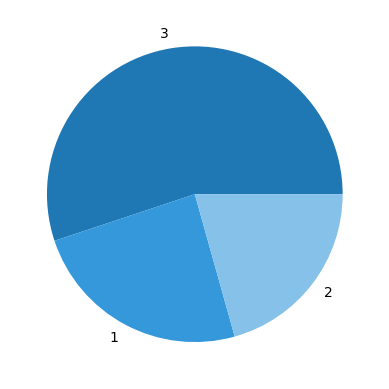

In [21]:
plt.pie(sayılar.values, labels=sayılar.index, colors=['#1f77b4', '#3498db', '#85c1e9'])
plt.show

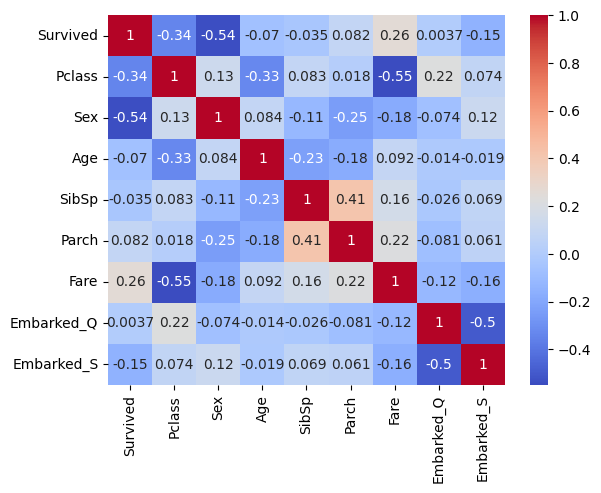

In [22]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [23]:
X = df.drop('Survived', axis=1)
y = df['Survived']

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [25]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [27]:
models = {

    "decision tree" : DecisionTreeClassifier(),
    "random forest" : RandomForestClassifier(),
    "svc" : SVC(),
    "logistic regression" : LogisticRegression(),
    "xgb" : XGBClassifier(),
}

In [28]:
def evaluate_models(models, X_train_scaled, y_train, X_test_scaled, y_test):
    results = []

    for name, model in models.items():

        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)


        accuracy = accuracy_score(y_test, y_pred)
        confusion = confusion_matrix(y_test, y_pred)
        classification = classification_report(y_test, y_pred)


        results.append({
            "name": name,
            "accuracy": accuracy
        })


        print(f"\nMODEL: {name}")
        print("=" * 40)
        print("Karmaşıklık Matrisi:")
        print(confusion)
        print("\nSınıflandırma Raporu:")
        print(classification)
        print(f"Accuracy: {accuracy:.4f}")


    return pd.DataFrame(results).sort_values(by=['accuracy'], ascending=False)




In [29]:
summary_table = evaluate_models(models, X_train_scaled, y_train, X_test_scaled, y_test)

print("\n" + "-" * 20)
print("GENEL KARŞILAŞTIRMA")
print("-" * 20)
print(summary_table.to_string(index=False))


MODEL: decision tree
Karmaşıklık Matrisi:
[[85 20]
 [20 54]]

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.81      0.81      0.81       105
           1       0.73      0.73      0.73        74

    accuracy                           0.78       179
   macro avg       0.77      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179

Accuracy: 0.7765

MODEL: random forest
Karmaşıklık Matrisi:
[[90 15]
 [19 55]]

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

Accuracy: 0.8101

MODEL: svc
Karmaşıklık Matrisi:
[[95 10]
 [22 52]]

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0

In [30]:
forest_params = {
    "n_estimators": [50, 10, 20, 30, 40],
    "criterion": ["gini", "entropy"],
    "max_depth": [5, 4, 3, None],
    "min_samples_split": [2, 1, 0.5]
}
from sklearn.model_selection import RandomizedSearchCV

In [31]:
search = RandomizedSearchCV(estimator=RandomForestClassifier(), param_distributions=forest_params, cv=5, n_jobs=-1)
search.fit(X_train_scaled, y_train)
y_pred = search.predict(X_test_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
20 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_

In [32]:
print(search.best_params_)
print(search.best_score_)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

{'n_estimators': 50, 'min_samples_split': 2, 'max_depth': 3, 'criterion': 'entropy'}
0.8117502216093767
0.7932960893854749
              precision    recall  f1-score   support

           0       0.77      0.92      0.84       105
           1       0.85      0.61      0.71        74

    accuracy                           0.79       179
   macro avg       0.81      0.77      0.77       179
weighted avg       0.80      0.79      0.79       179

[[97  8]
 [29 45]]
